In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import r3b
import seaborn as sns

%jsroot off

### Helper function to compare parameters from different files

In [2]:
def compare_par(par_name, pars, labels=[]):
    plot, axes = plt.subplots()
    axes.set_xticks(np.arange(0, 1301, step=100))
    axes.set_xticks(np.arange(0, 1301, step=50), minor=True)
    axes.tick_params(axis="x", labelsize=13, labelrotation=-30)
    axes.tick_params(axis="y", labelsize=13)
    axes.grid(which="both", axis="x")
    axes.grid(which="minor", alpha=0.5)
    plot.set_size_inches(13, 6)
    # df = pd.concat(list(pars.values()), ignore_index=True)
    data = pars
    if labels:
        data = data[data["label"].isin(labels)]
    sns.lineplot(data=data, x="bar_id", y=par_name, ax=axes, hue="label")
    return plot, axes

### Define parameter files with a unique label

Variables to setup:

- `root_path`: the root path used for the calibration of a certain experiment.
- `dir_path`: the subfolder name for a specific test
- `file_maps`: a dictionary with the parameter label as its key and parameter file name as its value

In [3]:
root_path = "/lustre/r3b/ywang/test/s122"
dir_path = "test_aug18"
file_maps = {
    "millepede": "millepede.par.root",
    "recons": "recons.par.root",
}

Read the parameter values from files:

In [4]:
all_pars = {}

for label, filename in file_maps.items():
    read_all = True if label == "millepede" else False
    dfs = r3b.neuland.HitParReader(
        filename=f"{root_path}/{dir_path}/{filename}", is_verbose=False
    ).read(read_all)
    if len(dfs) > 1:
        for cycle, df in dfs.items():
            iter_num = cycle - 1
            all_pars[f"{label}_{iter_num}"] = df
            all_pars[f"{label}_{iter_num}"]["iteration"] = iter_num
            all_pars[f"{label}_{iter_num}"]["label"] = f"{label}_{iter_num}"
    else:
        all_pars[f"{label}"] = list(dfs.values())[0]
        all_pars[f"{label}"]["iteration"] = -1
        all_pars[f"{label}"]["label"] = f"{label}"
all_pars = pd.concat(list(all_pars.values()), ignore_index=True)

In [5]:
reference_module_num = 25
ref_t_sync = all_pars[
    (all_pars["bar_id"] == (reference_module_num - 1)) & (all_pars["label"] == "recons")
]["t_sync.value"]
t_syncs = all_pars.loc[all_pars["label"] == "recons", "t_sync.value"]
t_syncs = t_syncs.sub(ref_t_sync.to_numpy()[0])
all_pars.loc[all_pars["label"] == "recons", "t_sync.value"] = t_syncs

## Check the value changes across iterations

Iteration number:
- `-1`: current method (muon track reconstruction)
- `0`: histogram method
- `1~8`: iterations of millepede parameter find tunning

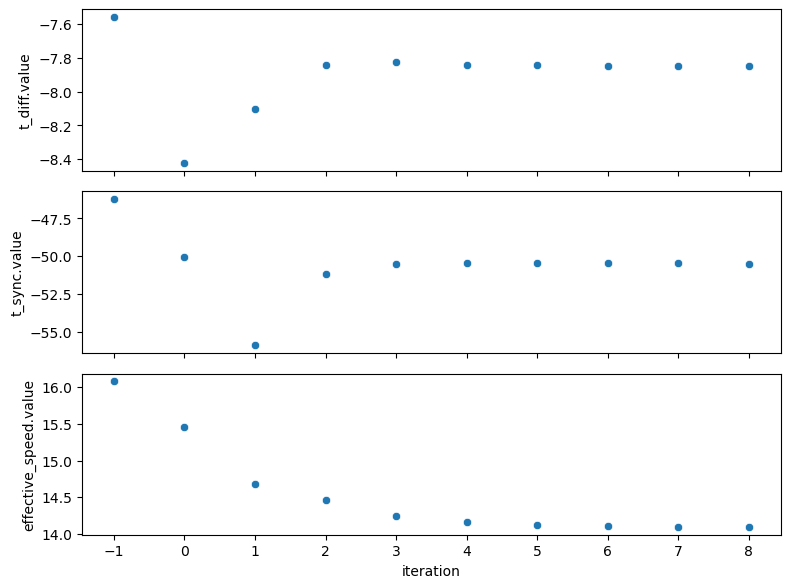

In [6]:
module_id = 756
selected_pars = all_pars[all_pars["bar_id"] == module_id]
# sns.set_context("notebook",rc={'axes.grid' : True})
# sns.set_theme(style="whitegrid")
g = sns.PairGrid(
    selected_pars,
    x_vars="iteration",
    y_vars=["t_diff.value", "t_sync.value", "effective_speed.value"],
    aspect=4,
    height=2,
    despine=False,
)
g.map(sns.scatterplot)
g.set(xticks=range(-1, all_pars["iteration"].max() + 1));

## Parameter comparisons

In [7]:
plot_labels = [
    "recons",
    "millepede_0",
    "millepede_1",
    f"millepede_{all_pars["iteration"].max()}",
]

### Comparison of t_sync parameter

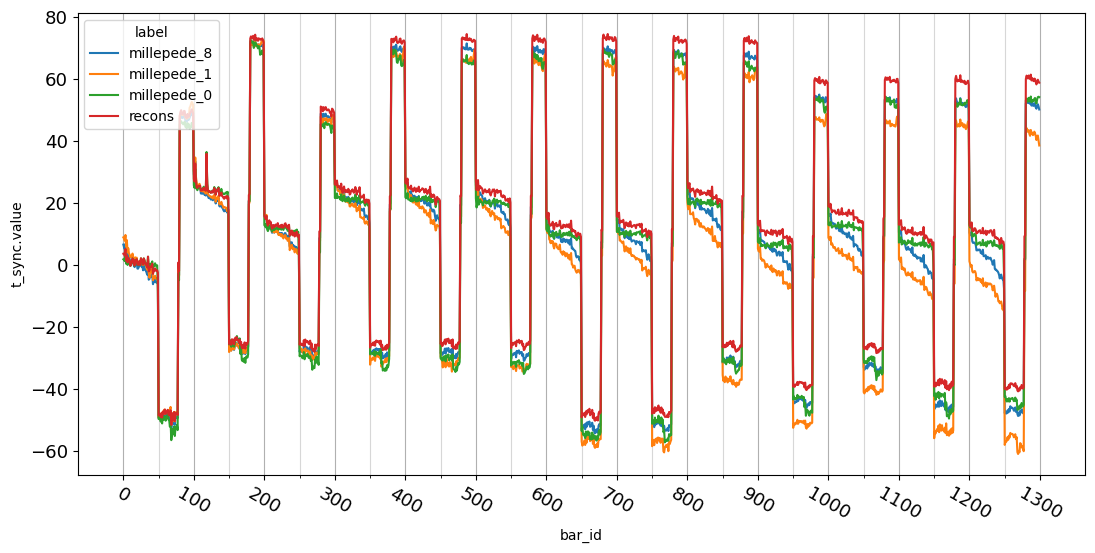

In [8]:
plot, axes = compare_par("t_sync.value", all_pars, plot_labels)
# axes.set(ylim=(-10, 20));
# axes.set(xlim=(1200, 1300))

### Comparison of t_diff parameter

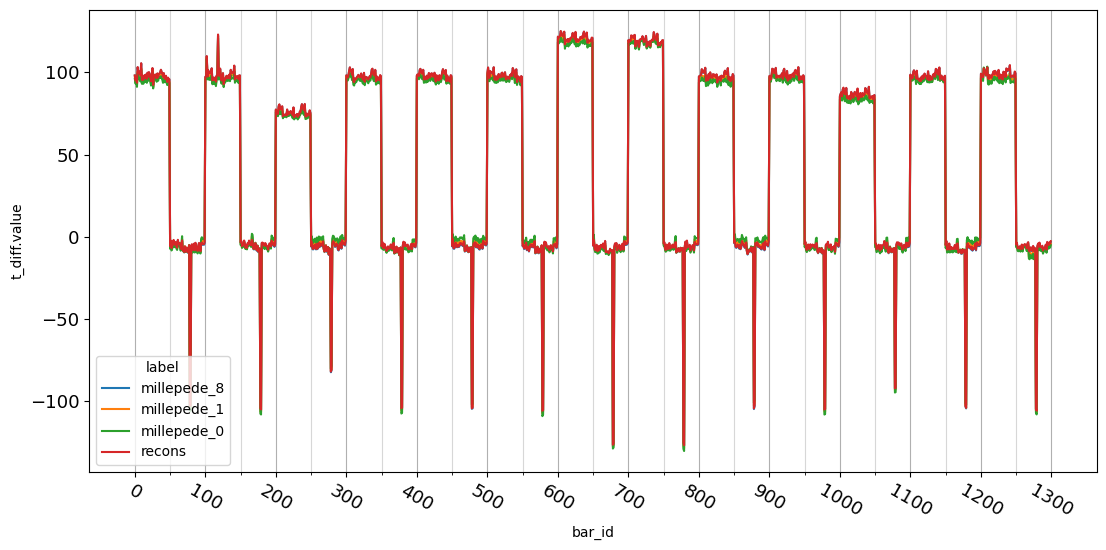

In [9]:
plot, axes = compare_par("t_diff.value", all_pars, plot_labels)
# axes.set(ylim=(-80, 80));

### Comparison of effective speed of light parameter

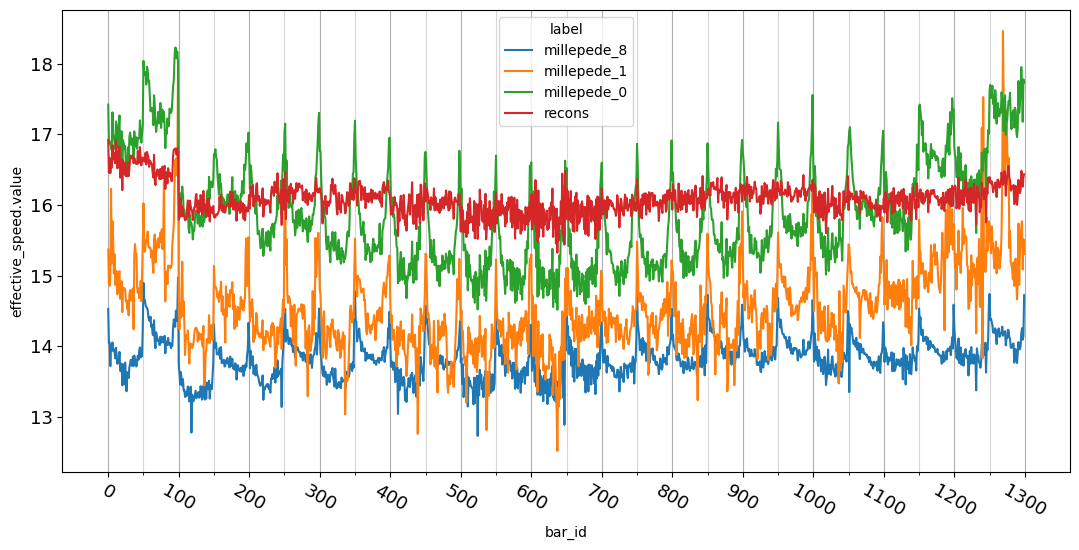

In [10]:
plot, axes = compare_par("effective_speed.value", all_pars, plot_labels)
# axes.set_ylim(10, 25)